# Regresión lineal múltiple

**CI-0148 Aprendizaje Automático — Universidad de Costa Rica**

Este cuaderno se trabaja de arriba hacia abajo: corra cada celda, lea la explicación y complete
las celdas marcadas con `## Complete:`. Las preguntas se responden en la celda de texto que las
sigue. Necesita el archivo **`auto-mpg.csv`** en el mismo directorio del cuaderno; es el mismo
conjunto de datos de la tarea de regresión lineal simple.

En aquella tarea la pregunta era modesta: predecir el peso de un automóvil a partir de su
cilindrada. Ahora la pregunta es la que de verdad importa: **predecir el rendimiento de
combustible (`mpg`) de un automóvil que el modelo nunca ha visto**, usando todo lo que se sabe
de él. Esa palabra —*nunca ha visto*— es la que separa el enfoque de aprendizaje automático del
enfoque estadístico clásico, y va a guiar todo el cuaderno.

### Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import RFECV
from sklearn.metrics import root_mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
pd.set_option('display.precision', 4)


## 1. Datos y preparación

El conjunto *Auto MPG* tiene 398 automóviles de 1970 a 1982. La variable objetivo es `mpg`
(millas por galón). Las variables candidatas a predictores son `cylinders`, `displacement`,
`horsepower`, `weight`, `acceleration`, `model_year` y `origin`.

In [2]:
autos = pd.read_csv('auto-mpg.csv')
autos.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


Hay dos cosas que resolver antes de modelar.

**Valores ausentes.** `horsepower` tiene 6 valores ausentes. Con 6 casos entre 398 la decisión
más honesta es descartarlos; imputarlos (por ejemplo con la regresión de la tarea anterior)
introduciría valores artificiales en la variable que estamos a punto de usar como predictor.

**La variable `origin` es categórica** (`usa`, `europe`, `japan`) y un modelo lineal solo
entiende números. La técnica estándar es la codificación *one-hot*: una columna indicadora
(0/1) por categoría. Se descarta una de las tres —la categoría de referencia— porque la tercera
columna sería combinación lineal exacta de las otras dos (si no es `usa` ni `japan`, es
`europe`). Eso es precisamente la **multicolinealidad perfecta** que el modelo no puede estimar;
en la literatura se le llama la *trampa de las variables ficticias* (dummy variable trap).

In [3]:
## Complete: descarte las filas con horsepower ausente, elimine la columna name
## (es un identificador, no un predictor) y codifique origin con one-hot, descartando
## una categoría como referencia. Guarde el resultado en `datos`.

datos = autos.dropna(subset=['horsepower']).drop(columns='name')
datos = pd.get_dummies(datos, columns=['origin'], drop_first=True, dtype=int)
datos.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,0,1
1,15.0,8,350.0,165.0,3693,11.5,70,0,1
2,18.0,8,318.0,150.0,3436,11.0,70,0,1
3,16.0,8,304.0,150.0,3433,12.0,70,0,1
4,17.0,8,302.0,140.0,3449,10.5,70,0,1


In [4]:
X = datos.drop(columns='mpg')
y = datos['mpg']
print('Predictores:', list(X.columns))
print('Observaciones:', len(X))

Predictores: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_japan', 'origin_usa']
Observaciones: 392


#### Preguntas
1. ¿Cuál quedó como categoría de referencia de `origin`? ¿Cómo se interpretará entonces el
   coeficiente de `origin_usa`?
2. ¿Qué pasaría si conservara las tres columnas indicadoras *y* el intercepto?

**Respuesta:**

1. europe. El coeficiente de origin_usa es la diferencia de mpg de un auto de EE. UU. frente a uno europeo, con el resto fijo.
2. Las tres dummies más el intercepto son linealmente dependientes (suman 1). El modelo no se puede estimar.


## 2. Protocolo de evaluación: la diferencia central con la estadística clásica

En un análisis estadístico tradicional se ajusta el modelo a *todos* los datos y se juzga por su
$R^2$, sus valores $p$ y su estadístico $F$. Todas esas cifras se calculan sobre los mismos datos
con los que se estimaron los coeficientes; miden qué tan bien el modelo *recuerda* la muestra,
no qué tan bien *generaliza*.

En aprendizaje automático el criterio es otro: el error en datos que el modelo no vio durante el
entrenamiento. Para poder medirlo se aparta desde el inicio un **conjunto de prueba**, que no se
toca hasta el final, cuando ya se eligió el modelo. Todas las decisiones intermedias —qué
variables incluir, qué regularización usar— se toman con **validación cruzada** dentro del
conjunto de entrenamiento.

Las métricas que usaremos son:

* **RMSE** (raíz del error cuadrático medio): está en las unidades de `mpg`, así que se lee
  directamente como «el modelo se equivoca típicamente en tantas millas por galón».
* **$R^2$ de prueba**: proporción de la varianza de `mpg` en el conjunto de prueba que el modelo
  explica. A diferencia del $R^2$ de entrenamiento, *puede* ser negativo si el modelo es peor que
  predecir la media.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Entrenamiento: {len(X_train)}   Prueba: {len(X_test)}')

# Validación cruzada de 5 pliegues, con la misma semilla para que sea reproducible
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluar(y_real, y_pred):
    """RMSE y R² de un vector de predicciones."""
    return {'RMSE': root_mean_squared_error(y_real, y_pred), 'R2': r2_score(y_real, y_pred)}

def rmse_cv(modelo, X, y):
    """RMSE promedio de validación cruzada sobre el conjunto de ENTRENAMIENTO."""
    puntajes = cross_val_score(modelo, X, y, cv=cv, scoring='neg_root_mean_squared_error')
    return -puntajes.mean()

# Aquí iremos acumulando los resultados de cada modelo en el conjunto de prueba
resultados = {}

Entrenamiento: 313   Prueba: 79


### Línea base

Toda comparación necesita un punto de referencia. El modelo más tonto posible predice la media
de `mpg` del conjunto de entrenamiento para cualquier automóvil. Cualquier modelo que valga la
pena debe superarlo con claridad.

In [6]:
base = DummyRegressor(strategy='mean').fit(X_train, y_train)
resultados['Línea base (media)'] = evaluar(y_test, base.predict(X_test))
resultados['Línea base (media)']

{'RMSE': 7.184726327203216, 'R2': -0.011357808240890499}

## 3. Punto de partida: regresión lineal simple

En la tarea anterior vimos que `weight` es el predictor individual más fuerte del rendimiento.
Empezamos por ahí para tener una segunda referencia.

In [7]:
## Complete: ajuste una regresión lineal simple de mpg sobre weight con el conjunto de
## entrenamiento y evalúela en el de prueba. Guarde el resultado en resultados['Simple: weight'].

simple = LinearRegression().fit(X_train[['weight']], y_train)
resultados['Simple: weight'] = evaluar(y_test, simple.predict(X_test[['weight']]))
resultados['Simple: weight']


{'RMSE': 4.206350944648542, 'R2': 0.6533466675646016}

## 4. Regresión lineal múltiple

Ajustamos ahora el modelo con todos los predictores. Usamos `statsmodels` porque su resumen
muestra los estadísticos que discutimos en clase: coeficientes con sus errores estándar y valores
$t$ y $p$, el $R^2$ ajustado y el estadístico $F$. **Importante:** el modelo se ajusta solo con
el conjunto de entrenamiento.

In [8]:
## Complete: ajuste con sm.OLS el modelo de mpg sobre todos los predictores
## (recuerde agregar la constante). Guárdelo como `ols_completo` y muestre el resumen.

ols_completo = sm.OLS(y_train, sm.add_constant(X_train)).fit()
ols_completo.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     183.8
Date:                Fri, 11 Sep 2026   Prob (F-statistic):          1.20e-111
Time:                        00:18:35   Log-Likelihood:                -816.67
No. Observations:                 313   AIC:                             1651.
Df Residuals:                     304   BIC:                             1685.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -16.4564      5.346     -3.079      0.002     -26.975      -5.937
cylinders       -0.3421      0.370     -0.924      0.356      -1.071       0.387
displacement     0.0192      0.009      2.222      0.027       0.002       0.036
horsepower      -0.0216      0.016     -1.391      0.165      -0.052       0.009
weight          -0.0064      0.001     -8.833      0.000      -0.008      -0.005
acceleration     0.0422      0.110      0.384      0.701      -0.174       0.258
model_year       0.7972      0.060     13.196      0.000       0.678       0.916
origin_japan     0.3305      0.664      0.497      0.619      -0.977       1.638
origin_usa      -2.8755      0.656     -4.384      0.000      -4.166      -1.585
==============================================================================
Omnibus:                       21.879   Durbin-Watson:                   1.988
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               28.418
Skew:                           0.538   Prob(JB):                     6.75e-07
Kurtosis:                       4.011   Cond. No.                     8.82e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.82e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [9]:
## Complete: evalúe el modelo en el conjunto de prueba y guarde el resultado
## en resultados['Múltiple: todas'].

resultados['Múltiple: todas'] = evaluar(y_test, ols_completo.predict(sm.add_constant(X_test)))
resultados['Múltiple: todas']


{'RMSE': 3.256114096847395, 'R2': 0.7922774714022589}

#### Preguntas
1. ¿Cuánto mejoró el RMSE de prueba respecto a la regresión simple? ¿Y respecto a la línea base?
2. El $R^2$ de entrenamiento que reporta el resumen, ¿es mayor o menor que el $R^2$ de prueba?
   ¿Por qué es esperable esa dirección?
3. ¿Qué coeficientes son significativos al 5 %? ¿Qué dice el estadístico $F$ sobre el modelo
   en conjunto?
4. Mire el **signo** del coeficiente de `displacement`. ¿Tiene sentido físico que un motor más
   grande, manteniendo constante todo lo demás, rinda *más* millas por galón? ¿Qué sospecha?

**Respuesta:**

1. Bajó de 4.21 a 3.26 mpg. Frente a la línea base (7.18) bajó 3.93.
2. Mayor el de entrenamiento (0.829 contra 0.792). Se calcula sobre los mismos datos con los que se estimaron los coeficientes.
3. Al 5 %: const, displacement, weight, model_year y origin_usa. F = 184, p ≈ 0. El modelo en conjunto es significativo.
4. No. Un motor más grande no rinde más mpg. displacement y weight ya venían casi juntos (0.93). El signo se invierte porque weight se lleva el efecto.


## 5. Diagnóstico de supuestos

En regresión múltiple los residuos se grafican contra los **valores ajustados** $\hat{y}$, no
contra un predictor, porque hay varios. Los tres diagnósticos básicos son:

* **Residuos contra ajustados.** Debe verse una banda horizontal sin patrón. Una curva delata
  forma funcional equivocada (violación de $E(\varepsilon \mid X) = 0$); un abanico delata
  heterocedasticidad.
* **Gráfico Q-Q** de los residuos contra los cuantiles de la normal. Sirve para la inferencia
  (valores $p$, intervalos), no para la predicción.
* **Prueba de Breusch-Pagan** de homocedasticidad. La hipótesis nula es varianza constante; un
  $p$ pequeño la rechaza.

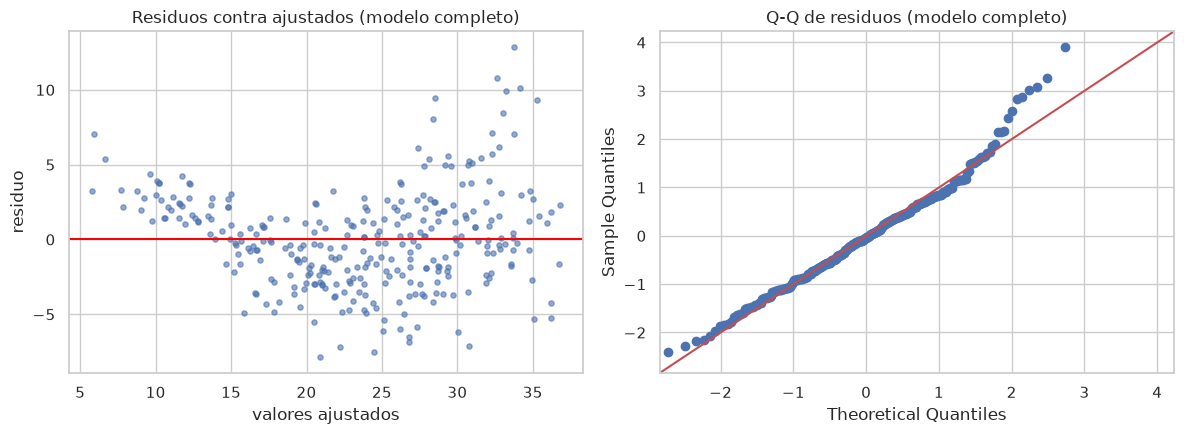

Breusch-Pagan: p = 0.0004568


In [10]:
def diagnostico(modelo, titulo=''):
    """Residuos contra ajustados y gráfico Q-Q para un modelo de statsmodels."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    ax[0].scatter(modelo.fittedvalues, modelo.resid, s=14, alpha=.6)
    ax[0].axhline(0, color='red')
    ax[0].set_xlabel('valores ajustados'); ax[0].set_ylabel('residuo')
    ax[0].set_title(f'Residuos contra ajustados {titulo}')
    sm.qqplot(modelo.resid, line='45', fit=True, ax=ax[1])
    ax[1].set_title(f'Q-Q de residuos {titulo}')
    plt.tight_layout(); plt.show()
    _, p_bp, _, _ = het_breuschpagan(modelo.resid, modelo.model.exog)
    print(f'Breusch-Pagan: p = {p_bp:.4g}')

diagnostico(ols_completo, '(modelo completo)')

#### Preguntas
1. ¿El modelo muestra homocedasticidad? Justifique con el gráfico y con la prueba.
2. ¿Ve algún patrón en el gráfico de residuos contra ajustados? ¿Qué supuesto pondría en duda?
3. ¿Los residuos parecen normales? ¿Para qué parte del análisis importa eso?

**Respuesta:**

1. No. El gráfico no es una banda de varianza constante y Breusch-Pagan da p = 0.00046.
2. Sí. Una U: positivos en los extremos y negativos en el centro. Se duda E(ε|X) = 0.
3. No del todo. Hay colas. Importa para los valores p y los intervalos, no para predecir.


## 6. Multicolinealidad

El signo absurdo de `displacement` pide una explicación. Empezamos por la matriz de correlación
entre los predictores y seguimos con el **factor de inflación de varianza** (VIF): para cada
predictor $X_j$ se regresa contra los demás predictores y se calcula
$\mathrm{VIF}_j = 1/(1 - R_j^2)$. Un VIF de 10 significa que la varianza del coeficiente es diez
veces mayor —y su error estándar $\sqrt{10} \approx 3.2$ veces mayor— de lo que sería si
$X_j$ fuera independiente de los demás.

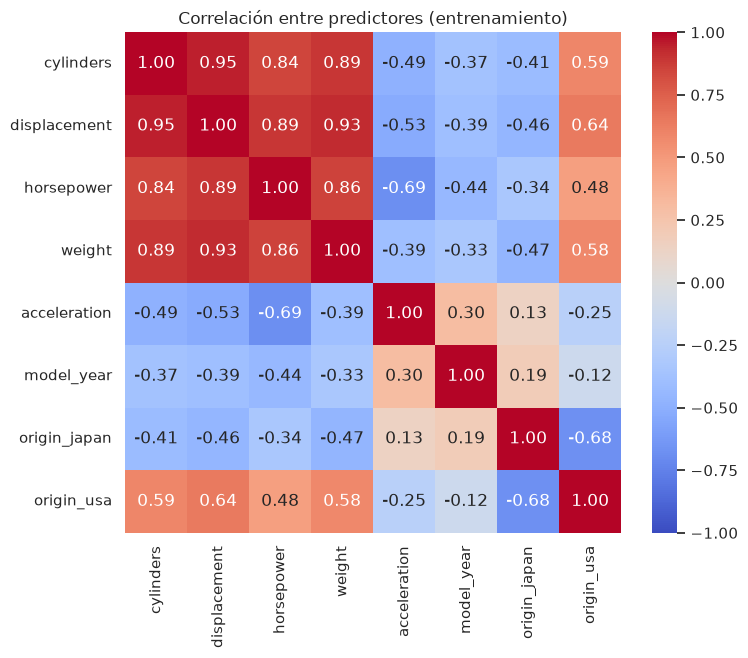

In [11]:
plt.figure(figsize=(8, 6.5))
sns.heatmap(X_train.corr(), annot=True, fmt='.2f', vmin=-1, vmax=1, center=0, cmap='coolwarm')
plt.title('Correlación entre predictores (entrenamiento)')
plt.show()

In [12]:
def calcular_vif(X):
    """VIF de cada columna de X. La constante se agrega solo para el cálculo y no se reporta."""
    Xc = sm.add_constant(X, has_constant='add')
    vifs = {col: variance_inflation_factor(Xc.values, i)
            for i, col in enumerate(Xc.columns) if col != 'const'}
    return pd.Series(vifs, name='VIF').sort_values(ascending=False)

calcular_vif(X_train)

displacement    22.5538
cylinders       11.1211
weight          10.4865
horsepower       9.9305
origin_usa       2.7696
acceleration     2.6830
origin_japan     1.9961
model_year       1.3480
Name: VIF, dtype: float64

#### Preguntas
1. ¿Qué variables tienen VIF mayor que 10? ¿Qué tienen en común?
2. Con el VIF y la matriz de correlación, explique el coeficiente positivo de `displacement`.
3. En clase se dijo que la multicolinealidad daña la interpretación de los coeficientes pero no
   necesariamente la predicción. ¿Cómo lo comprobaría con el protocolo de evaluación de este
   cuaderno?

**Respuesta:**

1. displacement (22.6), cylinders (11.1) y weight (10.5). Son el tamaño del motor/auto.
2. displacement va con cylinders (0.95) y weight (0.93). El efecto negativo del tamaño se lo queda weight; displacement queda con signo invertido.
3. Comparando el RMSE de prueba del modelo completo con el reducido. Si casi no cambia, la predicción no se dañó.


### Eliminación manual guiada por VIF

El procedimiento de clase: calcular el VIF, eliminar la variable con el VIF más alto, recalcular,
repetir hasta que todos queden por debajo del umbral. Usamos el criterio estricto, VIF < 5. La diferencia con el enfoque clásico es el
criterio para decidir si cada eliminación fue *buena*: no el valor $p$, sino el error fuera de
muestra estimado por validación cruzada **dentro del entrenamiento**. El conjunto de prueba sigue
intacto.

In [13]:
## Complete: implemente el ciclo de eliminación por VIF con umbral 5. En cada paso
## imprima la variable eliminada, el VIF máximo restante y el RMSE de validación cruzada
## del modelo con las variables que quedan. Al terminar, la lista `columnas` debe
## contener las variables sobrevivientes (las celdas siguientes la usan).

columnas = list(X_train.columns)
print(f'Inicial — RMSE CV: {rmse_cv(LinearRegression(), X_train[columnas], y_train):.4f}')
while True:
    vifs = calcular_vif(X_train[columnas])
    if vifs.max() < 5:
        break
    eliminar = vifs.idxmax()
    columnas.remove(eliminar)
    vif_max = calcular_vif(X_train[columnas]).max()
    rmse = rmse_cv(LinearRegression(), X_train[columnas], y_train)
    print(f'Eliminada: {eliminar:15s}  VIF máx restante: {vif_max:.2f}  RMSE CV: {rmse:.4f}')
print('Sobrevivientes:', columnas)


Inicial — RMSE CV: 3.3671
Eliminada: displacement     VIF máx restante: 9.22  RMSE CV: 3.3756
Eliminada: horsepower       VIF máx restante: 6.04  RMSE CV: 3.3726
Eliminada: cylinders        VIF máx restante: 2.30  RMSE CV: 3.3692
Sobrevivientes: ['weight', 'acceleration', 'model_year', 'origin_japan', 'origin_usa']


In [14]:
## Complete: ajuste con sm.OLS el modelo reducido (las columnas que quedaron),
## muestre el resumen y evalúelo en prueba como resultados['Múltiple: sin colineales'].

ols_reducido = sm.OLS(y_train, sm.add_constant(X_train[columnas])).fit()
print(ols_reducido.summary())
resultados['Múltiple: sin colineales'] = evaluar(
    y_test, ols_reducido.predict(sm.add_constant(X_test[columnas]))
)
resultados['Múltiple: sin colineales']


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     290.0
Date:                Fri, 11 Sep 2026   Prob (F-statistic):          5.48e-114
Time:                        00:18:36   Log-Likelihood:                -819.76
No. Observations:                 313   AIC:                             1652.
Df Residuals:                     307   BIC:                             1674.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -18.5542      4.574     -4.056   

{'RMSE': 3.3309839962501515, 'R2': 0.7826150549430146}

In [15]:
pd.DataFrame(resultados).T

,RMSE,R2
Línea base (media),7.1847,-0.0114
Simple: weight,4.2064,0.6533
Múltiple: todas,3.2561,0.7923
Múltiple: sin colineales,3.3310,0.7826


#### Preguntas
1. ¿Por qué cambian *todos* los VIF cuando se elimina una sola variable?
2. ¿Qué pasó con el RMSE de validación cruzada al eliminar las variables colineales? ¿Y con el
   RMSE de prueba?
3. Compare los coeficientes y los valores $p$ de `weight` en el modelo completo y en el reducido.
   ¿Qué ganó el modelo reducido?
4. ¿Sigue existiendo multicolinealidad? ¿Son significativos todos los coeficientes ahora?

**Respuesta:**

1. El VIF de cada una usa el R² contra las demás. Al quitar una, esos R² cambian.
2. El de CV casi no se movió (3.367 a 3.369). El de prueba empeoró poco (3.256 a 3.331).
3. Completo: β = −0.0064, t = −8.83. Reducido: β = −0.0059, t = −19.24. El reducido estima weight con menos error estándar.
4. No. Todos los VIF < 5. No. acceleration y origin_japan no son significativos.


## 7. Regularización: Ridge, LASSO y Elastic Net

La eliminación manual por VIF funciona, pero es artesanal. La **regresión regularizada** resuelve
el problema de forma automática: en lugar de minimizar solo el error cuadrático, minimiza
$\text{SSE} + \lambda \cdot \text{penalización}(\beta)$.

* **Ridge** (penalización L2, $\sum \beta_j^2$): encoge todos los coeficientes, ninguno llega a
  cero exacto. Estabiliza modelos con predictores colineales.
* **LASSO** (penalización L1, $\sum |\beta_j|$): lleva coeficientes débiles a cero exacto, así
  que hace selección de variables.
* **Elastic Net**: suma ambas penalizaciones.

Dos detalles de implementación que no son opcionales:

1. **Escalar los predictores.** La penalización castiga el tamaño de los coeficientes, y el
   tamaño de un coeficiente depende de las unidades de su variable: `weight` en libras tiene
   un coeficiente minúsculo y `cylinders` uno grande, solo por la escala. Sin estandarizar,
   la penalización caería casi toda sobre las variables de unidades pequeñas. Usamos un
   `Pipeline` para que el escalado se ajuste solo con los datos de entrenamiento de cada pliegue.
2. **Elegir $\lambda$ por validación cruzada.** En `scikit-learn` el parámetro se llama
   `alpha`. Las versiones `RidgeCV`, `LassoCV` y `ElasticNetCV` lo buscan automáticamente.

In [16]:
## Complete: construya tres pipelines (StandardScaler + RidgeCV / LassoCV / ElasticNetCV),
## ajústelos con el conjunto de entrenamiento y evalúelos en prueba. Guárdelos en el
## diccionario `regularizados` y sus resultados en `resultados`.

regularizados = {
    'Ridge': make_pipeline(StandardScaler(), RidgeCV(cv=cv)).fit(X_train, y_train),
    'LASSO': make_pipeline(StandardScaler(), LassoCV(cv=cv, max_iter=10_000)).fit(X_train, y_train),
    'Elastic Net': make_pipeline(
        StandardScaler(), ElasticNetCV(cv=cv, l1_ratio=[.1, .5, .7, .9, .95, .99, 1], max_iter=10_000)
    ).fit(X_train, y_train),
}
for nombre, modelo in regularizados.items():
    resultados[nombre] = evaluar(y_test, modelo.predict(X_test))
    print(nombre, resultados[nombre], 'alpha =', modelo[-1].alpha_)


Ridge {'RMSE': 3.2649141509821846, 'R2': 0.7911531621182973} alpha = 1.0
LASSO {'RMSE': 3.270905979475519, 'R2': 0.7903858998575793} alpha = 0.011598986953506866
Elastic Net {'RMSE': 3.281693660750979, 'R2': 0.7890009753140595} alpha = 0.013274733564794567


Para comparar coeficientes entre modelos hay que ponerlos en la misma escala. Ajustamos
también un MCO sobre los predictores estandarizados: así todos los coeficientes se leen como
«cambio en `mpg` por cada desviación estándar del predictor».

In [17]:
mco_escalado = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)

coeficientes = pd.DataFrame({'MCO': mco_escalado[-1].coef_}, index=X_train.columns)
for nombre, pipe in regularizados.items():
    coeficientes[nombre] = pipe[-1].coef_
coeficientes.round(3)

,MCO,Ridge,LASSO,Elastic Net
cylinders,-0.581,-0.519,-0.332,-0.357
displacement,1.990,1.719,1.448,1.216
horsepower,-0.826,-0.858,-0.742,-0.849
weight,-5.394,-5.192,-5.234,-4.921
acceleration,0.119,0.079,0.088,0.026
model_year,2.889,2.861,2.864,2.821
origin_japan,0.133,0.156,0.135,0.179
origin_usa,-1.376,-1.335,-1.306,-1.262


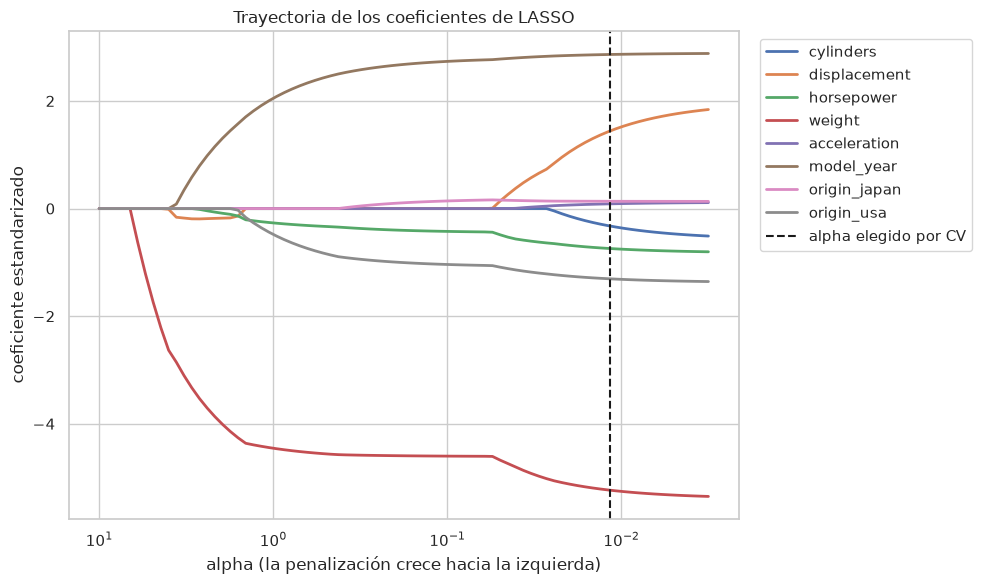

In [18]:
# Trayectoria de LASSO: cómo cambia cada coeficiente conforme crece la penalización
escalador = StandardScaler().fit(X_train)
alphas, trayectorias, _ = lasso_path(escalador.transform(X_train), y_train,
                                     alphas=np.logspace(-2.5, 1, 80))

plt.figure(figsize=(10, 6))
for coef, nombre in zip(trayectorias, X_train.columns):
    plt.plot(alphas, coef, lw=2, label=nombre)
plt.axvline(regularizados['LASSO'][-1].alpha_, color='k', ls='--', label='alpha elegido por CV')
plt.xscale('log'); plt.gca().invert_xaxis()
plt.xlabel('alpha (la penalización crece hacia la izquierda)'); plt.ylabel('coeficiente estandarizado')
plt.title('Trayectoria de los coeficientes de LASSO')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left'); plt.tight_layout(); plt.show()

#### Preguntas
1. Compare los tres modelos regularizados con el MCO completo en el conjunto de prueba. ¿Alguno
   mejora claramente?
2. ¿Qué coeficientes encoge más Ridge respecto al MCO? Relacione con los VIF.
3. Con el `alpha` elegido por validación cruzada, ¿LASSO llevó algún coeficiente a cero? ¿Por
   qué cree que eligió un `alpha` tan pequeño?
4. En la trayectoria de LASSO, ¿en qué orden desaparecen las variables al aumentar la
   penalización? ¿Cuáles son las dos últimas en sobrevivir? ¿Coincide con lo que esperaba?

**Respuesta:**

1. No. MCO 3.26. Ridge 3.27, LASSO 3.27, Elastic Net 3.28.
2. displacement, weight y cylinders. Son las de VIF alto.
3. No. El alpha quedó chico porque el MCO ya generaliza bien.
4. Primero cylinders y acceleration. Las dos últimas, weight y displacement. Weight era el predictor más fuerte de mpg.


## 8. Eliminación recursiva de características (RFE)

RFE es la contraparte de la eliminación manual por VIF: entrena el modelo, descarta la variable
con el coeficiente estandarizado más pequeño, y repite. `RFECV` decide además *cuántas* variables
conservar usando validación cruzada.

Número óptimo de variables: 5
Seleccionadas: ['displacement', 'horsepower', 'weight', 'model_year', 'origin_usa']


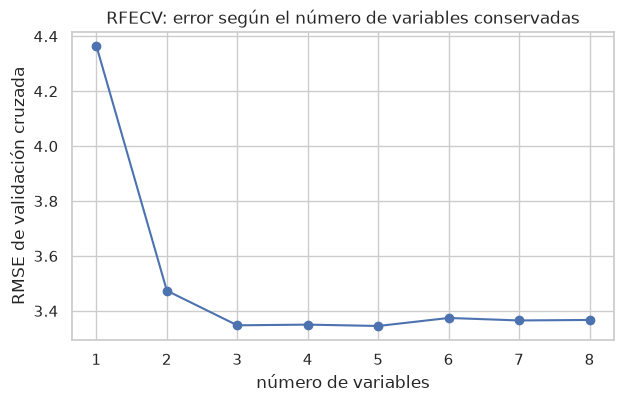

In [19]:
rfecv = RFECV(LinearRegression(), cv=cv, scoring='neg_root_mean_squared_error')
rfecv.fit(escalador.transform(X_train), y_train)

print('Número óptimo de variables:', rfecv.n_features_)
print('Seleccionadas:', list(X_train.columns[rfecv.support_]))

k = range(1, len(X_train.columns) + 1)
plt.figure(figsize=(7, 4))
plt.plot(k, -rfecv.cv_results_['mean_test_score'], 'o-')
plt.xlabel('número de variables'); plt.ylabel('RMSE de validación cruzada')
plt.title('RFECV: error según el número de variables conservadas')
plt.show()

#### Preguntas
1. ¿Cuántas variables recomienda RFECV? ¿Cuáles?
2. Compare la selección de RFE con la de la eliminación por VIF. ¿Por qué difieren, si el error de
   validación cruzada es casi el mismo?

**Respuesta:**

1. 5: displacement, horsepower, weight, model_year y origin_usa.
2. El VIF quita colineales. RFE se queda con las que más bajan el error, aunque estén correlacionadas. El CV es parecido porque dicen casi lo mismo.


## 9. La mejora que ninguna selección de variables puede dar: la forma funcional

Hasta aquí todas las variantes —completo, reducido, Ridge, LASSO, Elastic Net, RFE— quedaron
entre 3.26 y 3.34 mpg de error. Eso es una señal: el problema no está en *qué* variables usar
sino en *cómo* las usa el modelo. Los residuos de la sección 5 dibujaban una U, y en la tarea
anterior vimos por qué: las millas por galón son el recíproco del consumo, y la relación con el
peso es hiperbólica, no recta.

Una transformación logarítmica de la variable objetivo, $\log(\text{mpg})$, endereza esa
relación. El modelo sigue siendo *lineal en los parámetros*, que es lo que exige el supuesto 1;
solo cambia la escala en la que se mide $y$. Para evaluar en las unidades originales se aplica
$\exp$ a las predicciones.

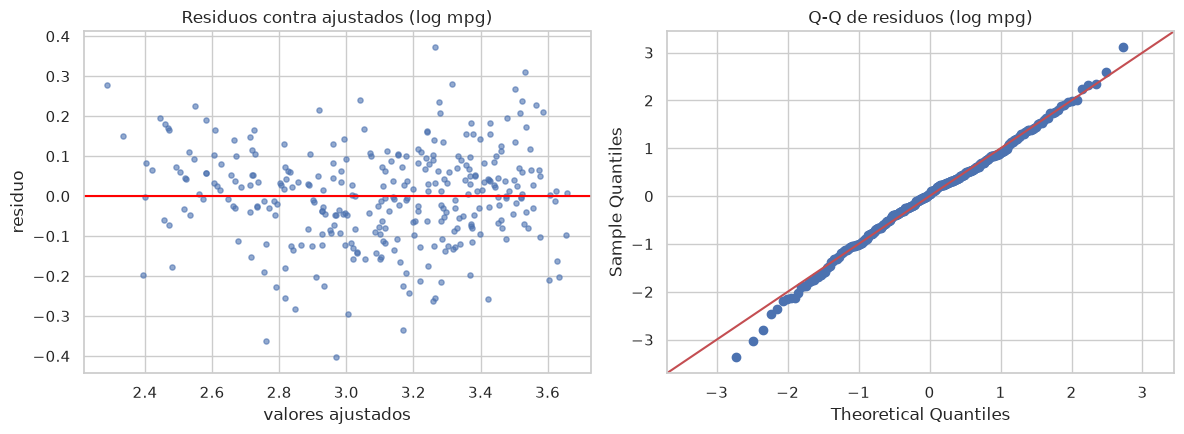

Breusch-Pagan: p = 0.2183


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     446.9
Date:                Fri, 11 Sep 2026   Prob (F-statistic):          1.50e-138
Time:                        00:18:36   Log-Likelihood:                 220.35
No. Observations:                 313   AIC:                            -428.7
Df Residuals:                     307   BIC:                            -406.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.4095      0.165      8.549      0.000       1.085       1.734
weight          -0.0003    1.1e-05    -25.438      0.000      -0.000      -0.000
acceleration     0.0043      0.003      1.570      0.118      -0.001       0.010
model_year       0.0331      0.002     15.997      0.000       0.029       0.037
origin_japan    -0.0095      0.024     -0.404      0.687      -0.056       0.037
origin_usa      -0.0862      0.022     -3.984      0.000      -0.129      -0.044
==============================================================================
Omnibus:                        4.453   Durbin-Watson:                   1.944
Prob(Omnibus):                  0.108   Jarque-Bera (JB):                4.511
Skew:                          -0.190   Prob(JB):                        0.105
Kurtosis:                       3.449   Cond. No.                     7.49e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [20]:
## Complete: ajuste con sm.OLS el modelo de log(mpg) sobre las columnas del modelo
## reducido (sección 6). Guárdelo como `ols_log`, corra diagnostico() sobre él y muestre el resumen.

ols_log = sm.OLS(np.log(y_train), sm.add_constant(X_train[columnas])).fit()
diagnostico(ols_log, '(log mpg)')
ols_log.summary()


In [21]:
## Complete: evalúe el modelo log en el conjunto de prueba, en las unidades originales
## de mpg, y guárdelo como resultados['Múltiple log: sin colineales'].

y_pred_log = np.exp(ols_log.predict(sm.add_constant(X_test[columnas])))
resultados['Múltiple log: sin colineales'] = evaluar(y_test, y_pred_log)
resultados['Múltiple log: sin colineales']


{'RMSE': 2.713083498257629, 'R2': 0.8557849146447711}

#### Preguntas
1. ¿Qué pasó con la U del gráfico de residuos? ¿Y con la prueba de Breusch-Pagan?
2. ¿Cuánto mejoró el RMSE de prueba? Compárelo con lo que consiguió la regularización.
3. En un modelo con $\log(y)$, un coeficiente $\beta_j$ pequeño se interpreta como un cambio
   porcentual aproximado de $100 \cdot \beta_j$ % en $y$ por unidad de $X_j$. Interprete así
   los coeficientes de `model_year`, `weight` (por cada 100 libras) y `origin_usa`.

**Respuesta:**

1. La U se aplana. Breusch-Pagan ya no rechaza (p = 0.22).
2. Bajó a 2.71. La regularización no había bajado el error.
3. model_year: +3.3 % en mpg por año. weight: −2.8 % por cada 100 lb. origin_usa: −8.6 % frente a Europa.


## 10. Comparación final y conclusiones

Ahora sí, con todas las decisiones tomadas, miramos el conjunto de prueba en su totalidad.

In [22]:
tabla = pd.DataFrame(resultados).T.sort_values('RMSE')
tabla.round(3)

,RMSE,R2
Múltiple log: sin colineales,2.713,0.856
Múltiple: todas,3.256,0.792
Ridge,3.265,0.791
LASSO,3.271,0.790
Elastic Net,3.282,0.789
Múltiple: sin colineales,3.331,0.783
Simple: weight,4.206,0.653
Línea base (media),7.185,-0.011


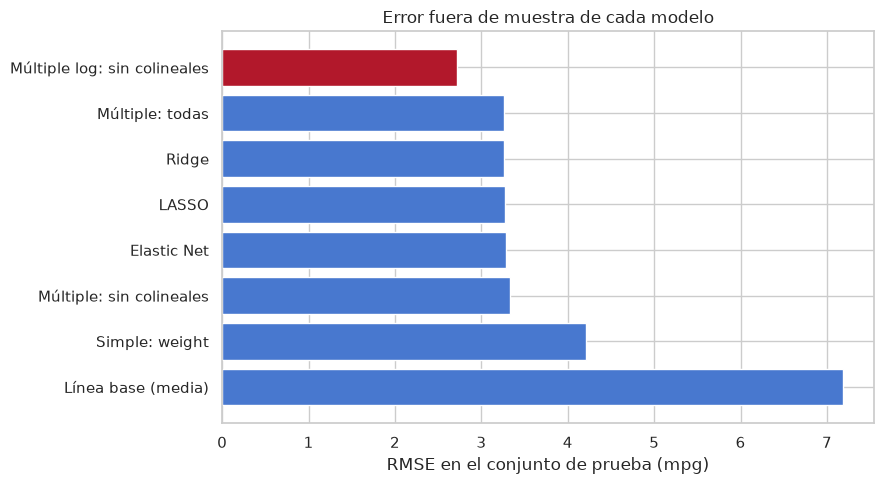

In [23]:
plt.figure(figsize=(9, 5))
plt.barh(tabla.index, tabla['RMSE'], color=['#b2182b'] + ['#4878cf'] * (len(tabla) - 1))
plt.xlabel('RMSE en el conjunto de prueba (mpg)')
plt.title('Error fuera de muestra de cada modelo')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

#### Preguntas finales
1. ¿Cuáles son los dos mejores modelos según el RMSE de prueba? ¿Cuál elegiría y por qué?
2. Escriba la ecuación del modelo elegido.
3. Un colega propone elegir el modelo con el $R^2$ de entrenamiento más alto. ¿Qué le
   respondería?
4. ¿Podemos usar este modelo para predecir el rendimiento de un automóvil de 2026? Explique.
5. Escriba una conclusión de un párrafo sobre qué aprendió de la diferencia entre *seleccionar
   variables* y *elegir la forma del modelo*.

**Respuesta:**

1. El log-reducido (2.71) y el MCO completo (3.26). Me quedo con el log. Mejor prueba y sin la U en residuos.
2. mpĝ = exp(1.410 − 0.000279 weight + 0.00426 acceleration + 0.0331 model_year − 0.00955 origin_japan − 0.0862 origin_usa)
3. Ese R² se calcula sobre los datos con los que se ajustó el modelo. Hay que mirar el error de prueba o de CV.
4. No. Los autos son de 1970 a 1982. Uno de 2026 queda fuera de rango.
5. Quitar variables dejó el RMSE en ~3.3. Pasar a log(mpg) lo bajó a 2.71. El problema no era cuáles variables usar. Era que mpg contra el tamaño no es una recta.


---
### Entrega

Entregue el cuaderno con toda la corrida. Si lo corrió en Visual Studio Code, cargue solo el
cuaderno; si lo corrió en Google Colaboratory, cargue el cuaderno y agregue un enlace compartido.